<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part IV · Preparing Data &nbsp;|&nbsp; Chapter 19</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Duplicates &amp; Inconsistencies <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five hands-on demos: drop exact duplicates the right way, standardize a messy category column, fix date and number formats, catch near-duplicates with string similarity, and codify validation rules that fail loudly.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | Exact deduplication | duplicated / drop_duplicates with subset & keep |
| 2 | Standardize categories | discover, map, verify: 6 labels collapse to 2 |
| 3 | Fix formats | mixed dates and text-numbers to clean types |
| 4 | Near-duplicates | string similarity flags "Jon" vs "John" |
| 5 | Validation rules | a contract the data must pass |

> Order matters: standardize BEFORE you dedup, and validate AFTER. Missing data is the next chapter.

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12.5,"axes.titleweight":"bold","axes.titlecolor":INK,"legend.frameon":False})
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · EXACT DEDUPLICATION</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">👯 duplicated, drop_duplicates, subset, keep</div>
<div style="color:#4a5578;margin-top:6px">duplicated() flags repeats without removing anything; drop_duplicates() removes them. subset= dedupes on a key (one row per customer), and keep= controls which row survives. keep=False isolates EVERY member of a duplicate group so you can inspect them.</div>
</div>

In [2]:
orders = pd.DataFrame({
    "order_id":   [101, 101, 102, 103, 103],
    "customer":   ["Ana","Ana","Ben","Cy","Cy"],
    "amount":     [50, 50, 30, 20, 99],     # note: order 103 has two DIFFERENT amounts
})
print("rows:", len(orders))
print("exact duplicate rows:", orders.duplicated().sum())          # row 1 is identical to row 0
print("\nisolate all members of any dup group (keep=False):")
print(orders[orders.duplicated(subset="order_id", keep=False)])

exact = orders.drop_duplicates()                       # all-column match -> drops the identical row 1
by_key = orders.drop_duplicates(subset="order_id", keep="last")  # one row per order_id, keep latest
print(f"\nafter drop_duplicates()              : {len(exact)} rows")
print(f"after drop_duplicates(subset=order_id): {len(by_key)} rows (collapses 103, keeps last)")
print("Removed", len(orders)-len(by_key), "rows. Always log how many you drop.")

rows: 5
exact duplicate rows: 1

isolate all members of any dup group (keep=False):
   order_id customer  amount
0       101      Ana      50
1       101      Ana      50
3       103       Cy      20
4       103       Cy      99

after drop_duplicates()              : 4 rows
after drop_duplicates(subset=order_id): 3 rows (collapses 103, keeps last)
Removed 2 rows. Always log how many you drop.


<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · STANDARDIZE CATEGORIES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🧹 Discover, map, verify</div>
<div style="color:#4a5578;margin-top:6px">The bread-and-butter fix. value_counts() reveals the variants, .str.strip().str.lower() removes casing and whitespace differences, a mapping dict collapses spellings to one canonical value, then value_counts() again confirms it.</div>
</div>

BEFORE ( 8 labels ):
gender
 Male     1
female    1
FEMALE    1
M         1
male      1
F         1
f         1
Female    1
Name: count, dtype: int64

AFTER ( 2 labels ):
gender
female    5
male      3
Name: count, dtype: int64


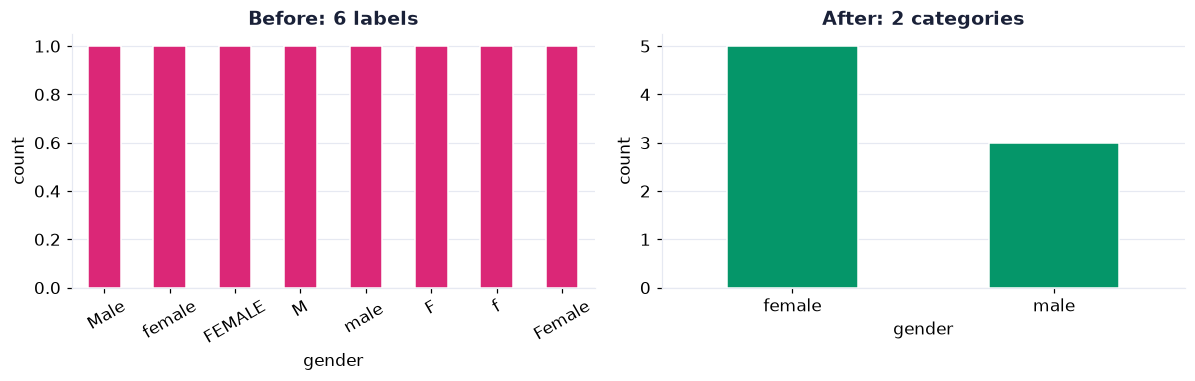

In [3]:
gender = pd.Series([" Male","female","FEMALE","M","male ","F","f","Female"], name="gender")
print("BEFORE (", gender.nunique(), "labels ):"); print(gender.value_counts())

clean = gender.str.strip().str.lower()                 # strip whitespace, unify case
mapping = {"m":"male", "male":"male", "f":"female", "female":"female"}
clean = clean.replace(mapping)                         # replace leaves unmatched as-is (map would NaN them)

print("\nAFTER (", clean.nunique(), "labels ):"); print(clean.value_counts())

fig, (a1,a2) = plt.subplots(1, 2, figsize=(11, 3.6))
gender.value_counts().plot.bar(ax=a1, color=PINK, edgecolor="white"); a1.set_title("Before: 6 labels"); a1.tick_params(axis="x", rotation=30)
clean.value_counts().plot.bar(ax=a2, color=GREEN, edgecolor="white"); a2.set_title("After: 2 categories"); a2.tick_params(axis="x", rotation=0)
for ax in (a1,a2): ax.grid(axis="x", visible=False); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · FIX FORMATS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📅 Dates and text-numbers to clean types</div>
<div style="color:#4a5578;margin-top:6px">Mixed date strings become real datetimes with pd.to_datetime; numbers hiding as text (commas, dollar signs) become numeric with pd.to_numeric. errors='coerce' turns the unparseable into NaT/NaN, so always count what you coerced.</div>
</div>

In [4]:
df = pd.DataFrame({
    "signup": ["2021-03-01","03/04/2021","2021/05/12","not a date","2021-08-15"],
    "spend":  ["1,200","$350","2000","N/A","1,500"],
})
df["signup"] = pd.to_datetime(df["signup"], errors="coerce", format="mixed")
df["spend"]  = pd.to_numeric(df["spend"].str.replace(r"[\$,]","",regex=True), errors="coerce")
print(df)
print(f"\ndtypes now: signup={df['signup'].dtype}, spend={df['spend'].dtype}")
print(f"coerced to missing -> signup: {df['signup'].isna().sum()}, spend: {df['spend'].isna().sum()}")
print("Those NaT/NaN are now missing data, which Chapter 20 picks up.")

      signup   spend
0 2021-03-01  1200.0
1 2021-03-04   350.0
2 2021-05-12  2000.0
3        NaT     NaN
4 2021-08-15  1500.0

dtypes now: signup=datetime64[us], spend=float64
coerced to missing -> signup: 1, spend: 1
Those NaT/NaN are now missing data, which Chapter 20 picks up.


<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · NEAR-DUPLICATES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔎 When the strings do not match exactly</div>
<div style="color:#4a5578;margin-top:6px">drop_duplicates only catches identical values. "Jon Smith" and "John Smith" are the same person to a human but different bytes to the computer. String-similarity scores (here a dependency-free Levenshtein ratio, 0 to 1) flag likely matches for review.</div>
</div>

pairwise similarity (>= 0.80 likely the same entity):
   'John Smith'   ~ 'Jon Smith'    -> 0.90
   'Jane Doe'     ~ 'Jane Doe '    -> 1.00

Review matches before merging: too loose a threshold merges two DIFFERENT real people.
In practice you would use rapidfuzz (pip install rapidfuzz) or a record-linkage library.


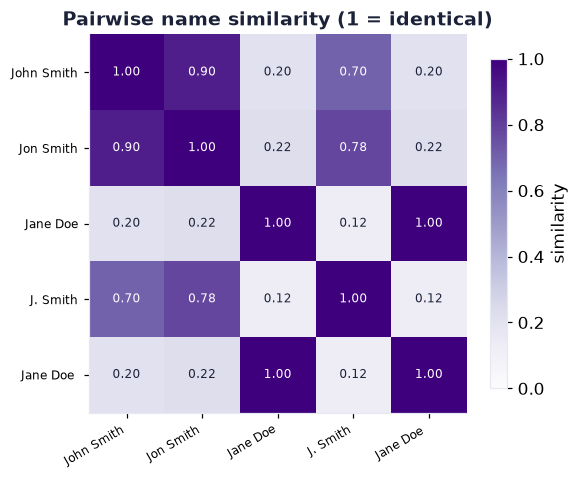

In [5]:
def lev_ratio(a, b):
    """Pure-python normalized Levenshtein similarity, 0..1 (1 = identical)."""
    m, n = len(a), len(b)
    d = list(range(n + 1))
    for i in range(1, m + 1):
        prev, d[0] = d[0], i
        for j in range(1, n + 1):
            cur = d[j]
            d[j] = min(d[j] + 1, d[j-1] + 1, prev + (a[i-1] != b[j-1]))
            prev = cur
    return 1 - d[n] / max(m, n, 1)

names = ["John Smith","Jon Smith","Jane Doe","J. Smith","Jane Doe "]
norm = [s.strip().lower() for s in names]               # standardize first!
print("pairwise similarity (>= 0.80 likely the same entity):")
for i in range(len(names)):
    for j in range(i+1, len(names)):
        r = lev_ratio(norm[i], norm[j])
        if r >= 0.80:
            print(f"   {names[i]!r:14} ~ {names[j]!r:14} -> {r:.2f}")
print("\nReview matches before merging: too loose a threshold merges two DIFFERENT real people.")
print("In practice you would use rapidfuzz (pip install rapidfuzz) or a record-linkage library.")

# --- added visual ---
import matplotlib.pyplot as plt, numpy as np
_CY,_PU,_AM,_GR,_PK,_INK,_GRY,_BL = "#0891b2","#7c3aed","#d97706","#059669","#db2777","#1a2138","#c7ccda","#2563eb"
M = np.array([[lev_ratio(norm[i], norm[j]) for j in range(len(names))] for i in range(len(names))])
fig, ax = plt.subplots(figsize=(5.4, 4.6))
im = ax.imshow(M, cmap="Purples", vmin=0, vmax=1)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=8, color="white" if M[i,j]>0.6 else _INK)
fig.colorbar(im, ax=ax, shrink=0.8, label="similarity")
ax.set_title("Pairwise name similarity (1 = identical)"); ax.grid(False)
plt.tight_layout(); plt.show()

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · VALIDATION RULES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📋 A contract the data must pass</div>
<div style="color:#4a5578;margin-top:6px">Codify what valid data looks like and check it, on ingest and again after cleaning. A validate() function that returns every violation makes cleaning a repeatable, testable pipeline. Fail loudly rather than silently coercing.</div>
</div>

In [6]:
people = pd.DataFrame({
    "id":     [1, 2, 3, 3],            # duplicate key
    "age":    [34, 200, 41, 27],       # 200 is impossible
    "gender": ["male","female","robot","male"],   # invalid category
    "email":  ["a@x.com","bad-email","c@x.com","d@x.com"],  # one malformed
})
VALID_GENDER = {"male","female","other"}
EMAIL_RE = r"^[^@\s]+@[^@\s]+\.[^@\s]+$"

def validate(df):
    issues = []
    if not df["id"].is_unique: issues.append(f"duplicate id: {df['id'][df['id'].duplicated()].tolist()}")
    if not df["age"].between(0,120).all(): issues.append(f"age out of range: {df.loc[~df['age'].between(0,120),'age'].tolist()}")
    bad_g = df.loc[~df["gender"].isin(VALID_GENDER), "gender"].tolist()
    if bad_g: issues.append(f"invalid gender: {bad_g}")
    bad_e = df.loc[~df["email"].str.match(EMAIL_RE), "email"].tolist()
    if bad_e: issues.append(f"malformed email: {bad_e}")
    return issues

violations = validate(people)
print("PASS ✅" if not violations else "FAIL ❌: {} rule(s) violated:".format(len(violations)))
for v in violations: print("   •", v)

FAIL ❌: 4 rule(s) violated:
   • duplicate id: [3]
   • age out of range: [200]
   • invalid gender: ['robot']
   • malformed email: ['bad-email']


## 👥 Real-World Example: A Contact List with Duplicates
A contact list with 207 rows but only 180 real people. First `drop_duplicates()` removes the **exact** copies, but a dozen **near**-duplicates survive, the same person whose name got re-cased or space-padded. Deduplicating on a business key (email) catches those too. Watch the row count fall in two stages, from raw to exact-clean to one-row-per-person.

raw rows                         : 207
after drop_duplicates() (exact)  : 192   (removed 15 exact copies)
after dedup on email (the key)   : 180   (removed 12 more near-duplicates)
true distinct people             : 180


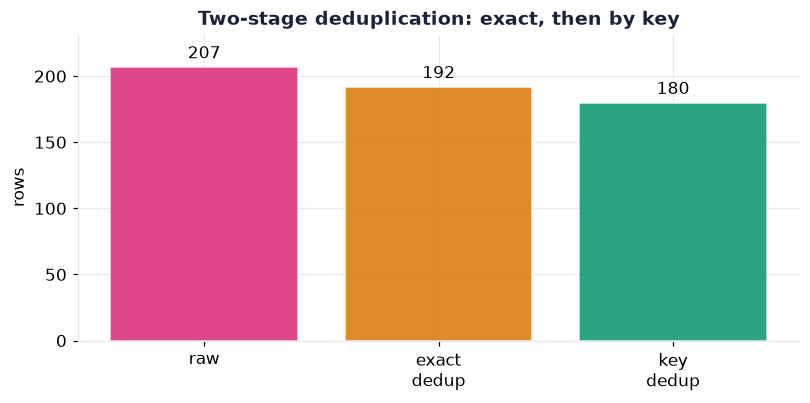

In [7]:
# --- Real-World beat: exact dedup vs key-based dedup ---
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    contacts = pd.read_excel("../../data/ch19_duplicate_contacts.xlsx", sheet_name="Data")
except FileNotFoundError: contacts = pd.read_excel(BASE+"ch19_duplicate_contacts.xlsx", sheet_name="Data")
n_raw = len(contacts)
n_exact = len(contacts.drop_duplicates())
n_key = len(contacts.drop_duplicates(subset="email"))
print(f"raw rows                         : {n_raw}")
print(f"after drop_duplicates() (exact)  : {n_exact}   (removed {n_raw-n_exact} exact copies)")
print(f"after dedup on email (the key)   : {n_key}   (removed {n_exact-n_key} more near-duplicates)")
print(f"true distinct people             : {contacts.email.nunique()}")
stages = ["raw", "exact\ndedup", "key\ndedup"]; counts = [n_raw, n_exact, n_key]
fig, ax = plt.subplots(figsize=(7.5,3.8))
bars = ax.bar(stages, counts, color=[PINK, AMBER, GREEN], alpha=0.85, edgecolor="white")
ax.bar_label(bars, fmt="%d", padding=3, fontsize=11)
ax.set_title("Two-stage deduplication: exact, then by key"); ax.set_ylabel("rows"); ax.set_ylim(0, n_raw*1.12)
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>drop_duplicates</b> removes exact repeats; use <b>subset</b> for a key and <b>keep</b> to choose which row survives.</li>
<li><b>Standardize</b> categories by discover (value_counts) to map (replace) to verify; strip whitespace and unify case first.</li>
<li><b>Fix formats</b> with pd.to_datetime / pd.to_numeric; errors='coerce' creates missing values, so count them.</li>
<li><b>Near-duplicates</b> need string similarity (Levenshtein, Jaro-Winkler); review matches to avoid false merges.</li>
<li><b>Validation rules</b> are a contract: range, type, allowed-value, format, uniqueness, cross-field. Fail loudly.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>